# Does a Competitive Scene Change Observable Fandom Behavior?

Part of `foundations/esports_vs_game_fandom_signal_model/` — Step 1 of that
brief's task list. Rather than trying to decompose a single viewership
number into "esports-fandom %" vs "game-fandom %" (not reliably answerable
with what this project collects), this notebook tests the comparative
reframe the brief proposes instead: does having an active competitive
scene measurably change a title's observable audience behavior?

**Three-way design**, not two:

1. A basket of non-esports titles from the platform-wide collector — never
   has an organized tournament apparatus at all.
2. Counter-Strike / Dota 2's own `general`-tier viewership — an esports
   title, but *not* currently tournament-influenced.
3. Counter-Strike / Dota 2's own `primary_official` + `detected_costream`
   viewership — the same titles, tournament-influenced.

If (1) ≈ (2) but (3) looks different, that's real evidence the
competitive apparatus itself is doing the work, not just "being a
notable esports title" in general. If (1) and (2) already differ, that's
a different, also-interesting finding this design can still surface.

**Why only Counter-Strike and Dota 2**: `config/channels.yaml` — the
input `primary_official` classification depends on — is curated for only
these two of 23 tracked titles. Extending this comparison to more titles
is `esports_vs_game_fandom_signal_model/brief.md`'s own Step 2, not done
here.


In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from etl.db import get_connection

conn = get_connection()
plt.rcParams["figure.dpi"] = 110


## Refreshing broadcast_tier first

`etl/classify_broadcast_tier.py` is a classification pass, not something
that runs automatically at capture time — new `is_official_broadcast=1`
rows accumulate from `twitch_poll.py` as CS/Dota2's curated channels go
live, but stay `broadcast_tier=NULL` until this script re-runs. Checked
directly before building this notebook: 242,228 previously-unclassified
rows existed, including 119 real `primary_official` rows that had never
been surfaced. Re-run as part of this notebook's own setup, not assumed
current.

In [2]:
import subprocess
result = subprocess.run(
    [sys.executable, str(REPO_ROOT / "etl" / "classify_broadcast_tier.py")],
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)


0 row(s) to classify (incremental, unclassified only)



## Signal 1 — within-title: tournament-adjacent vs. general viewership

`broadcast_tier`: `primary_official` (curated official channel) and
`detected_costream` (title/date/alias match against a live tournament,
catches co-streamers too) are pooled as "tournament-adjacent" — kept
separate from `general` (everything else).

In [3]:
tier_rows = conn.execute('''
    SELECT title_id, broadcast_tier, channel_id, viewer_count, language
    FROM viewership_snapshots
    WHERE title_id IN ('counter_strike', 'dota2') AND broadcast_tier IS NOT NULL
''').fetchall()
tier_df = pd.DataFrame(tier_rows, columns=["title_id", "broadcast_tier", "channel_id", "viewer_count", "language"])
tier_df["group"] = tier_df["broadcast_tier"].map({
    "primary_official": "tournament-adjacent",
    "detected_costream": "tournament-adjacent",
    "general": "general",
})

within_title = tier_df.groupby(["title_id", "group"]).agg(
    rows=("viewer_count", "size"),
    distinct_channels=("channel_id", "nunique"),
    avg_viewers=("viewer_count", "mean"),
    median_viewers=("viewer_count", "median"),
    total_viewer_time=("viewer_count", "sum"),
).round(1)

# Top-channel concentration share within each (title, group)
def top_channel_share(g):
    by_channel = g.groupby("channel_id")["viewer_count"].sum()
    return round(by_channel.max() / by_channel.sum() * 100, 1) if by_channel.sum() > 0 else float("nan")

within_title["top_channel_share_pct"] = tier_df.groupby(["title_id", "group"]).apply(top_channel_share, include_groups=False)
within_title


rows  distinct_channels  avg_viewers  \
title_id       group                                                        
counter_strike general              52918              18727         80.8   
               tournament-adjacent   1361                211       2115.5   
dota2          general              34288               8929        119.6   
               tournament-adjacent     73                 15        184.4   

                                    median_viewers  total_viewer_time  \
title_id       group                                                    
counter_strike general                         8.0            4276018   
               tournament-adjacent           238.0            2879197   
dota2          general                         9.0            4100577   
               tournament-adjacent            48.0              13460   

                                    top_channel_share_pct  
title_id       group                                       
counter_strike general                                5.8  
               tournament-adjacent                   14.5  
dota2          general                                4.2  
               tournament-adjacent                   35.8

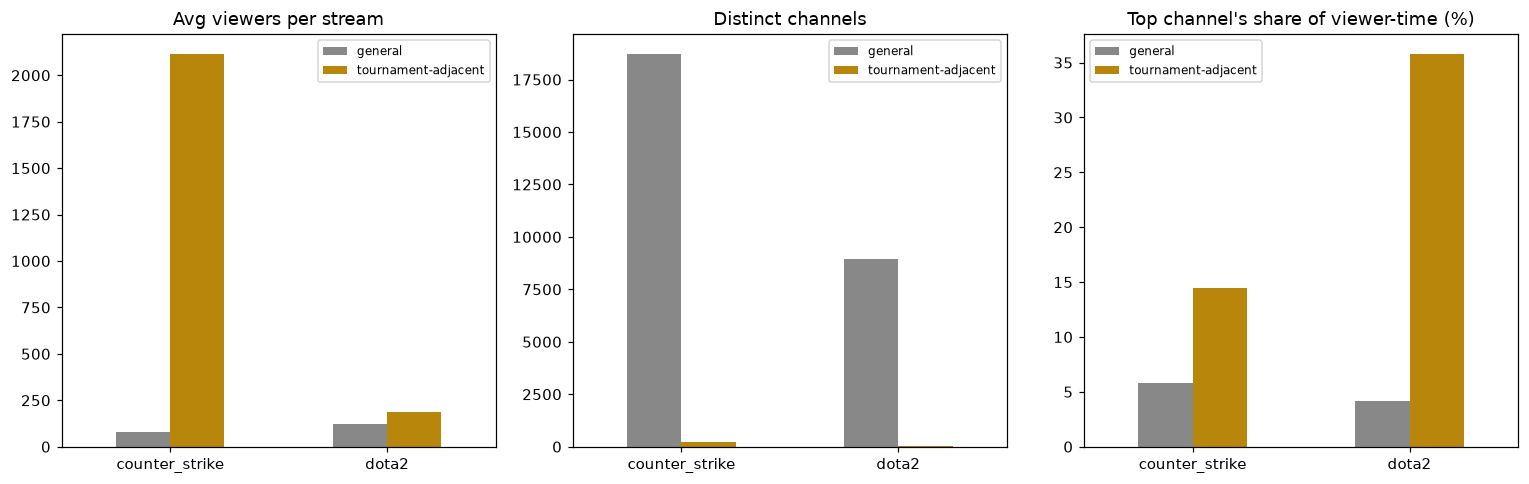

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
plot_df = within_title.reset_index()

for ax, metric, title in zip(
    axes,
    ["avg_viewers", "distinct_channels", "top_channel_share_pct"],
    ["Avg viewers per stream", "Distinct channels", "Top channel's share of viewer-time (%)"],
):
    pivot = plot_df.pivot(index="title_id", columns="group", values=metric)
    pivot = pivot[["general", "tournament-adjacent"]]
    pivot.plot(kind="bar", ax=ax, color=["#888888", "#b8860b"])
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(Path.cwd() / "_signal_fig1_within_title.png", dpi=110)
plt.show()


## Signal 2 — the external baseline: non-esports platform-wide viewership

**A first-pass, scoped non-game exclusion list** — `wider_game_fandoms/brief.md`'s
own open item (a real non-game category list) is *not built* project-wide;
this is a narrower list built for this notebook's own comparison, not a
claim to have closed that gap. Built from the actual top `game_name`
values by viewer-time in `platform_viewership_snapshots`, checked live,
not guessed.

**Grand Theft Auto V is excluded from the general non-esports basket
deliberately**, not an oversight — its own nested NoPixel RP-scene
structure (`wider_game_fandoms/gta_launch_case_study/`) is exactly the
kind of internal complexity this baseline needs to *not* have, to stay a
clean "no competitive apparatus, no other known structure" comparison.

In [5]:
NON_GAME_CATEGORIES = {
    "Just Chatting", "IRL", "Music", "Sports", "Slots", "Always On",
    "Virtual Casino", "ASMR", "Art", "DJs", "Special Events", "Talk Shows",
}
EXCLUDED_IDIOSYNCRATIC = {"Grand Theft Auto V"}

baseline_rows = conn.execute('''
    SELECT game_name, channel_id, viewer_count, language
    FROM platform_viewership_snapshots
''').fetchall()
baseline_df = pd.DataFrame(baseline_rows, columns=["game_name", "channel_id", "viewer_count", "language"])
before_n = len(baseline_df)
baseline_df = baseline_df[~baseline_df["game_name"].isin(NON_GAME_CATEGORIES | EXCLUDED_IDIOSYNCRATIC)]
print(f"{before_n} raw rows -> {len(baseline_df)} after excluding {len(NON_GAME_CATEGORIES)} non-game categories and GTA V ({before_n - len(baseline_df)} rows dropped)")

baseline_summary = pd.Series({
    "rows": len(baseline_df),
    "distinct_channels": baseline_df["channel_id"].nunique(),
    "avg_viewers": round(baseline_df["viewer_count"].mean(), 1),
    "median_viewers": round(baseline_df["viewer_count"].median(), 1),
    "top_channel_share_pct": top_channel_share(baseline_df),
})
baseline_summary


1434914 raw rows -> 1200990 after excluding 12 non-game categories and GTA V (233924 rows dropped)


rows                     1200990.0
distinct_channels         480287.0
avg_viewers                   30.9
median_viewers                 5.0
top_channel_share_pct          1.7
dtype: float64

## Three-way comparison

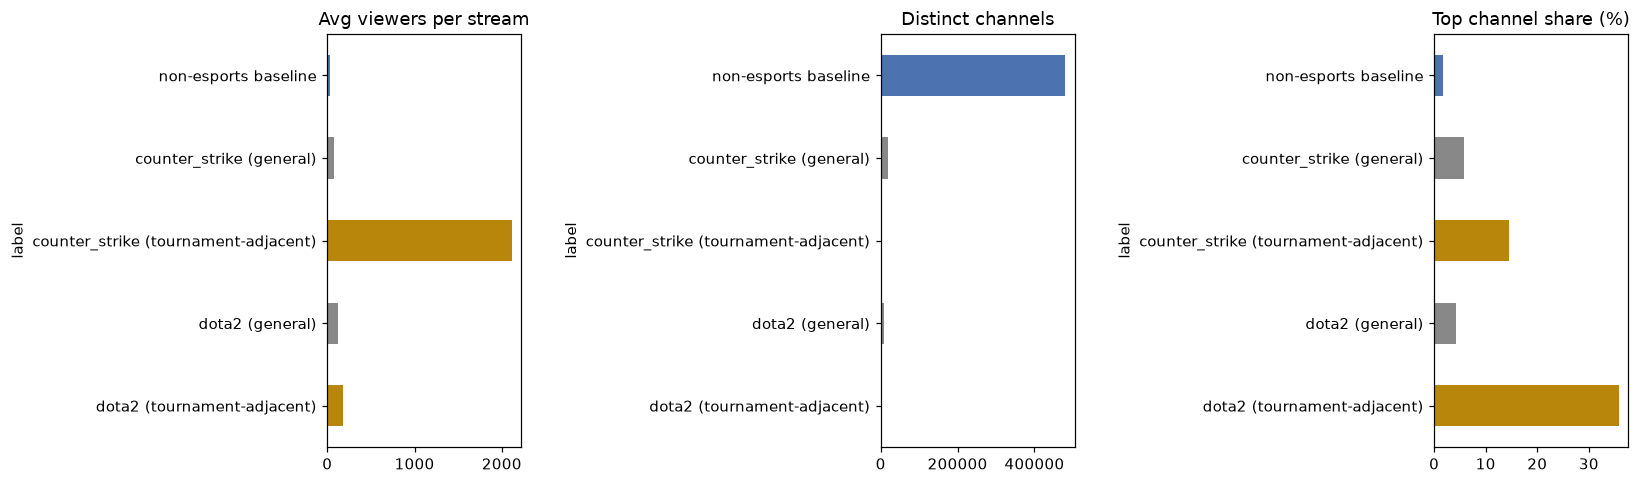

,avg_viewers,distinct_channels,top_channel_share_pct
label,,,
non-esports baseline,30.9,480287.0,1.7
counter_strike (general),80.8,18727.0,5.8
counter_strike (tournament-adjacent),2115.5,211.0,14.5
dota2 (general),119.6,8929.0,4.2
dota2 (tournament-adjacent),184.4,15.0,35.8


In [6]:
three_way = within_title.reset_index()
three_way["label"] = three_way["title_id"] + " (" + three_way["group"] + ")"
three_way = three_way.set_index("label")[["avg_viewers", "distinct_channels", "top_channel_share_pct"]]
three_way.loc["non-esports baseline"] = [
    baseline_summary["avg_viewers"], baseline_summary["distinct_channels"], baseline_summary["top_channel_share_pct"],
]
three_way = three_way.loc[[
    "non-esports baseline",
    "counter_strike (general)", "counter_strike (tournament-adjacent)",
    "dota2 (general)", "dota2 (tournament-adjacent)",
]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = ["#4c72b0", "#888888", "#b8860b", "#888888", "#b8860b"]
for ax, col, title in zip(axes, three_way.columns, ["Avg viewers per stream", "Distinct channels", "Top channel share (%)"]):
    three_way[col].plot(kind="barh", ax=ax, color=colors)
    ax.set_title(title)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(Path.cwd() / "_signal_fig2_three_way.png", dpi=110)
plt.show()
three_way


## Signal 3 — language mix, same three groups

A different dimension of "does behavior change": does the *audience
composition* shift, not just its size/concentration.

In [7]:
def lang_shares(df, top_n=6):
    counts = df.groupby("language")["viewer_count"].sum().sort_values(ascending=False)
    shares = (counts / counts.sum() * 100).round(1)
    return shares.head(top_n)

print("=== non-esports baseline ===")
print(lang_shares(baseline_df))
print()
for (tid, grp), g in tier_df.groupby(["title_id", "group"]):
    print(f"=== {tid} ({grp}) ===")
    print(lang_shares(g))
    print()


=== non-esports baseline ===
language
en    58.5
de     7.5
ru     7.4
es     5.6
fr     5.0
ja     5.0
Name: viewer_count, dtype: float64

=== counter_strike (general) ===
language
ru    47.1
en    18.2
pt    13.6
pl     8.1
es     3.3
fr     1.9
Name: viewer_count, dtype: float64

=== counter_strike (tournament-adjacent) ===
language
ru    60.2
en    27.2
fr     3.0
fi     1.9
pt     1.8
uk     1.4
Name: viewer_count, dtype: float64

=== dota2 (general) ===
language
ru    74.7
en    19.0
pt     3.8
uk     1.0
es     0.4
de     0.3
Name: viewer_count, dtype: float64

=== dota2 (tournament-adjacent) ===
language
ru    79.2
tl     8.2
en     5.6
uk     3.4
th     3.3
pt     0.4
Name: viewer_count, dtype: float64



## Reading the result

**Esports titles already differ from the non-esports baseline before any
tournament effect.** CS's and Dota 2's own `general`-tier average viewer
count (80.8 / 119.6) runs 2.5-4x higher than the non-esports platform-wide
baseline (30.9), even outside any tournament window. Being a tracked,
notable esports title is already a different regime from typical Twitch
content -- worth remembering before attributing everything below to the
tournament effect specifically.

**Counter-Strike shows a clean, large tournament effect on every metric.**
Average viewers per stream jumps ~26x (80.8 -> 2,115.5) moving from
`general` to tournament-adjacent, median jumps ~30x (8 -> 238), and
concentration roughly triples (top channel's share 5.8% -> 14.5%). This
is the shape the brief's reframe predicted: a real, large, multi-metric
shift when a competitive scene is actively live.

**Dota 2's tournament effect looks much weaker on raw average viewers
(119.6 -> 184.4, only ~1.5x) -- investigated, not left as a surprising
anomaly.** The `primary_official` tier alone averages just 30 viewers
across 25 rows, dragging the pooled tournament-adjacent average down
despite `detected_costream`'s much higher 264.8 average on its own 48
rows. The likely explanation, grounded in how `config/channels.yaml` was
actually curated: Dota 2's curated list is 22 channels, mostly *regional*
ESL/PGL feeds, against CS's 9 more flagship-weighted channels (BLAST/ESL
mains, not just regional mirrors) -- so "primary_official" for Dota 2
disproportionately captures smaller secondary broadcasts, not the single
biggest feed. **Concentration tells the more consistent story**: Dota 2's
top-channel share still jumps sharply (4.2% -> 35.8%, proportionally the
largest jump of either title) -- attention concentrating into fewer
channels during a tournament holds for both titles, even though raw
average viewers alone is confounded by channel-list composition. This is
the same caution `esports_lifecycle_and_maturity/brief.md` §15 already
established for `avg_viewer_ratio` (CS vs. VALORANT): a raw per-channel
average is not safely comparable across differently-composed channel
populations, within one title across time exactly as much as across
titles.

**Language mix reveals two separate, real findings, not one.** First:
both esports titles are already heavily Russian-dominant in general
viewing (CS 47.1% ru, Dota 2 74.7% ru) -- starkly different from the
non-esports baseline's English-dominant, more evenly-spread mix (58.5%
en, next-largest only 7.5%). That's a pre-existing audience-composition
difference the tournament doesn't create. Second: the tournament-window
shift isn't uniform across titles -- CS's tournament audience skews
further toward EN+RU together (en rises 18.2% -> 27.2%), while Dota 2's
tournament window *reduces* English share (19.0% -> 5.6%) and pulls in
Filipino and Thai viewers instead (tl 8.2%, th 3.3%, both near-zero in
Dota 2's general mix) -- consistent with which specific regional feeds
happened to be live and curated, not a generic "tournaments skew English"
effect.

**What this means for the brief's actual task (defining esports fandom
operationally)**: concentration (top-channel share) looks like the most
robust, least-confounded signal across both titles -- average viewer
count alone is vulnerable to exactly the channel-list-composition
confound found here. Worth weighting concentration more heavily than raw
average viewers when Step 3 (the operational definition) gets written.
